In [25]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from fishsense_imwut.camera import reconstruct_points
from matplotlib.patches import Ellipse

## Setup of Simulation
The following reasonable defaults that match the systems we tested against.

In [26]:
IMAGE_WIDTH, IMAGE_HEIGHT = 4014, 3016
FOCAL_LENGTH_PX = 2850
LASER_DIAMETER_M = 5.6 * 1e-3  # Convert mm to meters

IMAGE_WIDTH, IMAGE_HEIGHT, FOCAL_LENGTH_PX, LASER_DIAMETER_M

(4014, 3016, 2850, 0.0056)

In [27]:
camera_intrinsics = np.array([
    [FOCAL_LENGTH_PX, 0, IMAGE_WIDTH / 2],
    [0, FOCAL_LENGTH_PX, IMAGE_HEIGHT / 2],
    [0, 0, 1]
])
inverted_camera_intrinsics = np.linalg.inv(camera_intrinsics)

camera_intrinsics, inverted_camera_intrinsics

(array([[2.850e+03, 0.000e+00, 2.007e+03],
        [0.000e+00, 2.850e+03, 1.508e+03],
        [0.000e+00, 0.000e+00, 1.000e+00]]),
 array([[ 3.50877193e-04,  0.00000000e+00, -7.04210526e-01],
        [ 0.00000000e+00,  3.50877193e-04, -5.29122807e-01],
        [ 0.00000000e+00,  0.00000000e+00,  1.00000000e+00]]))

In [28]:
laser_position = np.array([-0.04, -0.11, 0])
laser_direction = np.array([1e-10, 1e-10, 1])

laser_params = np.concatenate([laser_direction, laser_position[:2]])

laser_position, laser_direction, laser_params

(array([-0.04, -0.11,  0.  ]),
 array([1.e-10, 1.e-10, 1.e+00]),
 array([ 1.0e-10,  1.0e-10,  1.0e+00, -4.0e-02, -1.1e-01]))

## Next we setup data we can use for testing

In [29]:
STEP_COUNT = 1000
t = np.linspace(0, 30, STEP_COUNT)

STEP_COUNT, t

(1000,
 array([ 0.        ,  0.03003003,  0.06006006,  0.09009009,  0.12012012,
         0.15015015,  0.18018018,  0.21021021,  0.24024024,  0.27027027,
         0.3003003 ,  0.33033033,  0.36036036,  0.39039039,  0.42042042,
         0.45045045,  0.48048048,  0.51051051,  0.54054054,  0.57057057,
         0.6006006 ,  0.63063063,  0.66066066,  0.69069069,  0.72072072,
         0.75075075,  0.78078078,  0.81081081,  0.84084084,  0.87087087,
         0.9009009 ,  0.93093093,  0.96096096,  0.99099099,  1.02102102,
         1.05105105,  1.08108108,  1.11111111,  1.14114114,  1.17117117,
         1.2012012 ,  1.23123123,  1.26126126,  1.29129129,  1.32132132,
         1.35135135,  1.38138138,  1.41141141,  1.44144144,  1.47147147,
         1.5015015 ,  1.53153153,  1.56156156,  1.59159159,  1.62162162,
         1.65165165,  1.68168168,  1.71171171,  1.74174174,  1.77177177,
         1.8018018 ,  1.83183183,  1.86186186,  1.89189189,  1.92192192,
         1.95195195,  1.98198198,  2.0120120

In [30]:
p = laser_position[:, np.newaxis] + t[np.newaxis, :] * laser_direction[:, np.newaxis]

p

array([[-0.04      , -0.04      , -0.04      , ..., -0.04      ,
        -0.04      , -0.04      ],
       [-0.11      , -0.11      , -0.11      , ..., -0.11      ,
        -0.11      , -0.11      ],
       [ 0.        ,  0.03003003,  0.06006006, ..., 29.93993994,
        29.96996997, 30.        ]], shape=(3, 1000))

In [31]:
s = p / p[2, :]
s = camera_intrinsics @ s

s

/tmp/ipykernel_27507/932217983.py:1: RuntimeWarning: divide by zero encountered in divide
  s = p / p[2, :]
/tmp/ipykernel_27507/932217983.py:1: RuntimeWarning: invalid value encountered in divide
  s = p / p[2, :]
/tmp/ipykernel_27507/932217983.py:2: RuntimeWarning: invalid value encountered in matmul
  s = camera_intrinsics @ s


array([[            nan, -1.78920000e+03,  1.08900000e+02, ...,
         2.00319238e+03,  2.00319619e+03,  2.00320000e+03],
       [            nan, -8.93155000e+03, -3.71177500e+03, ...,
         1.49752904e+03,  1.49753953e+03,  1.49755000e+03],
       [            nan,  1.00000000e+00,  1.00000000e+00, ...,
         1.00000000e+00,  1.00000000e+00,  1.00000000e+00]],
      shape=(3, 1000))

In [32]:
s_pixel = np.round(s)

s_pixel

array([[       nan, -1.789e+03,  1.090e+02, ...,  2.003e+03,  2.003e+03,
         2.003e+03],
       [       nan, -8.932e+03, -3.712e+03, ...,  1.498e+03,  1.498e+03,
         1.498e+03],
       [       nan,  1.000e+00,  1.000e+00, ...,  1.000e+00,  1.000e+00,
         1.000e+00]], shape=(3, 1000))

  0%|          | 0/1000 [00:00<?, ?it/s]

/home/chris/Repos/school/e4e/fishsense/imwut-2026-fishsense-lite_python/fishsense_imwut/camera.py:39: RuntimeWarning: divide by zero encountered in divide
  point_constants_noisy = (
/home/chris/Repos/school/e4e/fishsense/imwut-2026-fishsense-lite_python/fishsense_imwut/camera.py:43: RuntimeWarning: invalid value encountered in multiply
  world_points = np.tile(point_constants_noisy, (3, 1)) * final_laser_axis


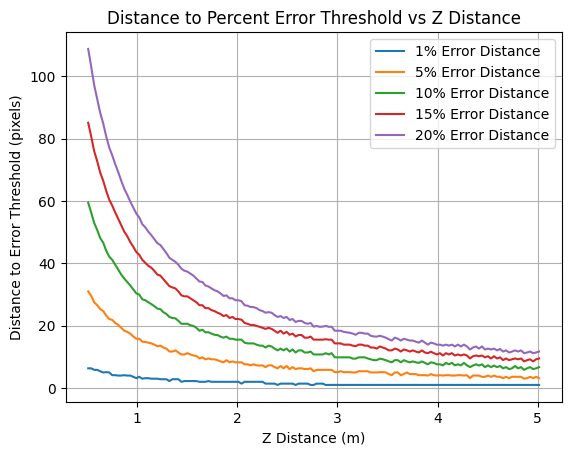

In [33]:
z_values = []
one_percent_error_distance = []
five_percent_error_distance = []
ten_percent_error_distance = []
fifteen_percent_error_distance = []
twenty_percent_error_distance = []

for i in tqdm(range(s_pixel.shape[1])):
    if p[2, i] < 0.5:
        continue

    heat_map = np.zeros((IMAGE_WIDTH, IMAGE_HEIGHT), dtype=float)

    x_range = np.arange(0, IMAGE_WIDTH)
    y_range = np.arange(0, IMAGE_HEIGHT)

    xy_grid = np.array(np.meshgrid(x_range, y_range, indexing='ij'))
    xy_homogeneous = np.vstack((xy_grid.reshape(2, -1), np.ones((1, xy_grid.shape[1] * xy_grid.shape[2]))))

    p_reconstructed, _ = reconstruct_points(xy_homogeneous, inverted_camera_intrinsics, laser_position, laser_direction)
    percent_errors = np.abs(p_reconstructed[2, :] - p[2, i]) / p[2, i] * 100
    distances = np.linalg.norm(xy_homogeneous[:2, :] - np.tile(s_pixel[:2, i], (xy_homogeneous.shape[1], 1)).T, axis=0)

    one_percent_error_distance.append(distances[distances == np.min(distances[percent_errors > 1])][0])
    five_percent_error_distance.append(distances[distances == np.min(distances[percent_errors > 5])][0])
    ten_percent_error_distance.append(distances[distances == np.min(distances[percent_errors > 10])][0])
    fifteen_percent_error_distance.append(distances[distances == np.min(distances[percent_errors > 15])][0])
    twenty_percent_error_distance.append(distances[distances == np.min(distances[percent_errors > 20])][0])

    z_values.append(p[2, i])

    if p[2, i] > 5:
        break

one_percent_error_distance, five_percent_error_distance, ten_percent_error_distance, fifteen_percent_error_distance, twenty_percent_error_distance, z_values

plt.plot(z_values, one_percent_error_distance, label='1% Error Distance')
plt.plot(z_values, five_percent_error_distance, label='5% Error Distance')
plt.plot(z_values, ten_percent_error_distance, label='10% Error Distance')
plt.plot(z_values, fifteen_percent_error_distance, label='15% Error Distance')
plt.plot(z_values, twenty_percent_error_distance, label='20% Error Distance')
plt.xlabel('Z Distance (m)')
plt.ylabel('Distance to Error Threshold (pixels)')
plt.title('Distance to Percent Error Threshold vs Z Distance')
plt.legend()
plt.grid()

  0%|          | 0/1000 [00:00<?, ?it/s]

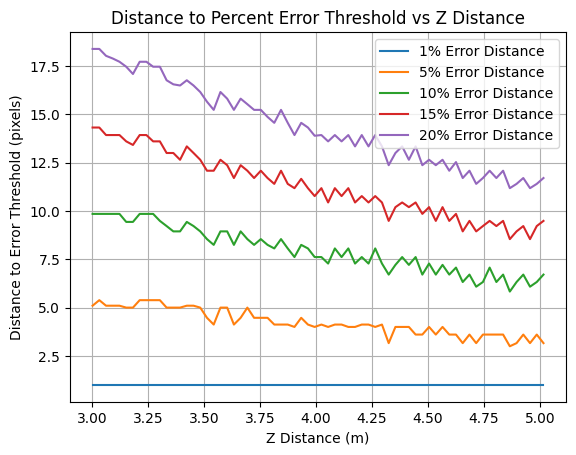

In [34]:
z_values = []
one_percent_error_distance = []
five_percent_error_distance = []
ten_percent_error_distance = []
fifteen_percent_error_distance = []
twenty_percent_error_distance = []

for i in tqdm(range(s_pixel.shape[1])):
    if p[2, i] < 3:
        continue

    heat_map = np.zeros((IMAGE_WIDTH, IMAGE_HEIGHT), dtype=float)

    x_range = np.arange(0, IMAGE_WIDTH)
    y_range = np.arange(0, IMAGE_HEIGHT)

    xy_grid = np.array(np.meshgrid(x_range, y_range, indexing='ij'))
    xy_homogeneous = np.vstack((xy_grid.reshape(2, -1), np.ones((1, xy_grid.shape[1] * xy_grid.shape[2]))))

    p_reconstructed, _ = reconstruct_points(xy_homogeneous, inverted_camera_intrinsics, laser_position, laser_direction)
    percent_errors = np.abs(p_reconstructed[2, :] - p[2, i]) / p[2, i] * 100
    distances = np.linalg.norm(xy_homogeneous[:2, :] - np.tile(s_pixel[:2, i], (xy_homogeneous.shape[1], 1)).T, axis=0)

    one_percent_error_distance.append(distances[distances == np.min(distances[percent_errors > 1])][0])
    five_percent_error_distance.append(distances[distances == np.min(distances[percent_errors > 5])][0])
    ten_percent_error_distance.append(distances[distances == np.min(distances[percent_errors > 10])][0])
    fifteen_percent_error_distance.append(distances[distances == np.min(distances[percent_errors > 15])][0])
    twenty_percent_error_distance.append(distances[distances == np.min(distances[percent_errors > 20])][0])

    z_values.append(p[2, i])

    if p[2, i] > 5:
        break

one_percent_error_distance, five_percent_error_distance, ten_percent_error_distance, fifteen_percent_error_distance, twenty_percent_error_distance, z_values

plt.plot(z_values, one_percent_error_distance, label='1% Error Distance')
plt.plot(z_values, five_percent_error_distance, label='5% Error Distance')
plt.plot(z_values, ten_percent_error_distance, label='10% Error Distance')
plt.plot(z_values, fifteen_percent_error_distance, label='15% Error Distance')
plt.plot(z_values, twenty_percent_error_distance, label='20% Error Distance')
plt.xlabel('Z Distance (m)')
plt.ylabel('Distance to Error Threshold (pixels)')
plt.title('Distance to Percent Error Threshold vs Z Distance')
plt.legend()
plt.grid()

  0%|          | 0/1000 [00:00<?, ?it/s]

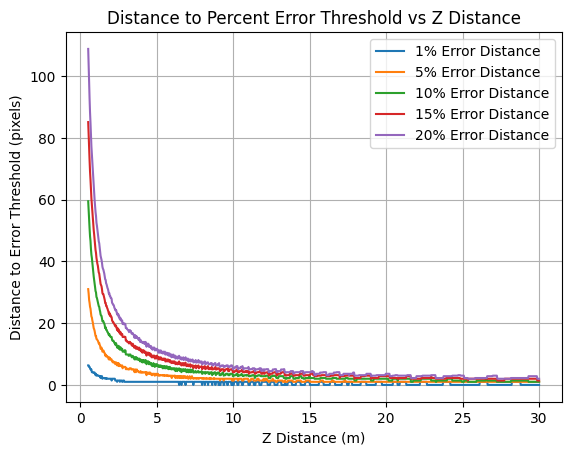

In [35]:
z_values = []
one_percent_error_distance = []
five_percent_error_distance = []
ten_percent_error_distance = []
fifteen_percent_error_distance = []
twenty_percent_error_distance = []

for i in tqdm(range(s_pixel.shape[1])):
    if p[2, i] < 0.5:
        continue
    
    heat_map = np.zeros((IMAGE_WIDTH, IMAGE_HEIGHT), dtype=float)

    x_range = np.arange(0, IMAGE_WIDTH)
    y_range = np.arange(0, IMAGE_HEIGHT)

    xy_grid = np.array(np.meshgrid(x_range, y_range, indexing='ij'))
    xy_homogeneous = np.vstack((xy_grid.reshape(2, -1), np.ones((1, xy_grid.shape[1] * xy_grid.shape[2]))))

    p_reconstructed, _ = reconstruct_points(xy_homogeneous, inverted_camera_intrinsics, laser_position, laser_direction)
    percent_errors = np.abs(p_reconstructed[2, :] - p[2, i]) / p[2, i] * 100
    distances = np.linalg.norm(xy_homogeneous[:2, :] - np.tile(s_pixel[:2, i], (xy_homogeneous.shape[1], 1)).T, axis=0)

    one_percent_error_distance.append(distances[distances == np.min(distances[percent_errors > 1])][0])
    five_percent_error_distance.append(distances[distances == np.min(distances[percent_errors > 5])][0])
    ten_percent_error_distance.append(distances[distances == np.min(distances[percent_errors > 10])][0])
    fifteen_percent_error_distance.append(distances[distances == np.min(distances[percent_errors > 15])][0])
    twenty_percent_error_distance.append(distances[distances == np.min(distances[percent_errors > 20])][0])

    z_values.append(p[2, i])

one_percent_error_distance, five_percent_error_distance, ten_percent_error_distance, fifteen_percent_error_distance, twenty_percent_error_distance, z_values

plt.plot(z_values, one_percent_error_distance, label='1% Error Distance')
plt.plot(z_values, five_percent_error_distance, label='5% Error Distance')
plt.plot(z_values, ten_percent_error_distance, label='10% Error Distance')
plt.plot(z_values, fifteen_percent_error_distance, label='15% Error Distance')
plt.plot(z_values, twenty_percent_error_distance, label='20% Error Distance')
plt.xlabel('Z Distance (m)')
plt.ylabel('Distance to Error Threshold (pixels)')
plt.title('Distance to Percent Error Threshold vs Z Distance')
plt.legend()
plt.grid()

In [36]:
p_left = p.copy()
p_left[0, :] -= LASER_DIAMETER_M / 2

p_right = p.copy()
p_right[0, :] += LASER_DIAMETER_M / 2

p_up = p.copy()
p_up[1, :] += LASER_DIAMETER_M / 2

p_down = p.copy()
p_down[1, :] -= LASER_DIAMETER_M / 2

p_left[:, 0], p_right[:, 0], p_up[:, 0], p_down[:, 0]

(array([-0.0428, -0.11  ,  0.    ]),
 array([-0.0372, -0.11  ,  0.    ]),
 array([-0.04  , -0.1072,  0.    ]),
 array([-0.04  , -0.1128,  0.    ]))

In [37]:
s_left = p_left / p_left[2, :]
s_left = camera_intrinsics @ s_left

s_right = p_right / p_right[2, :]
s_right = camera_intrinsics @ s_right

s_up = p_up / p_up[2, :]
s_up = camera_intrinsics @ s_up

s_down = p_down / p_down[2, :]
s_down = camera_intrinsics @ s_down

s_left[:, 0], s_right[:, 0], s_up[:, 0], s_down[:, 0]

/tmp/ipykernel_27507/292300546.py:1: RuntimeWarning: divide by zero encountered in divide
  s_left = p_left / p_left[2, :]
/tmp/ipykernel_27507/292300546.py:1: RuntimeWarning: invalid value encountered in divide
  s_left = p_left / p_left[2, :]
/tmp/ipykernel_27507/292300546.py:2: RuntimeWarning: invalid value encountered in matmul
  s_left = camera_intrinsics @ s_left
/tmp/ipykernel_27507/292300546.py:4: RuntimeWarning: divide by zero encountered in divide
  s_right = p_right / p_right[2, :]
/tmp/ipykernel_27507/292300546.py:4: RuntimeWarning: invalid value encountered in divide
  s_right = p_right / p_right[2, :]
/tmp/ipykernel_27507/292300546.py:5: RuntimeWarning: invalid value encountered in matmul
  s_right = camera_intrinsics @ s_right
/tmp/ipykernel_27507/292300546.py:7: RuntimeWarning: divide by zero encountered in divide
  s_up = p_up / p_up[2, :]
/tmp/ipykernel_27507/292300546.py:7: RuntimeWarning: invalid value encountered in divide
  s_up = p_up / p_up[2, :]
/tmp/ipykernel_

(array([nan, nan, nan]),
 array([nan, nan, nan]),
 array([nan, nan, nan]),
 array([nan, nan, nan]))

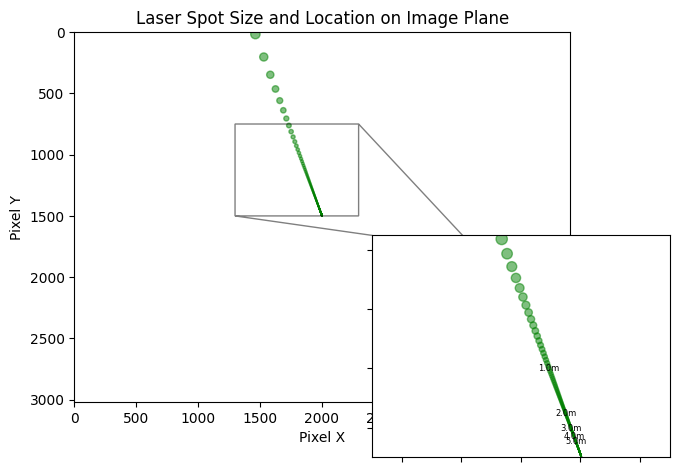

In [75]:
fig, ax = plt.subplots()

prev_z_value_shown = -1
x1, x2 = 1300, 2300
y1, y2 = 750, 1500
axins = ax.inset_axes([0.6, -0.15, 0.6, 0.6], xlim=(x1, x2), ylim=(y1, y2), xticklabels=[], yticklabels=[])

for idx in range(s.shape[1]):
    center_x = s[0, idx]
    center_y = s[1, idx]

    width = s_right[0, idx] - s_left[0, idx]
    height = s_up[1, idx] - s_down[1, idx]

    z_value = int(p[2, idx])
    if z_value != prev_z_value_shown and z_value < 6:
        # ax.text(center_x, center_y, f'{p[2, idx]:.1f}m', color='black', fontsize=8, ha='center', va='center')
        axins.text(center_x, center_y, f'{p[2, idx]:.1f}m', color='black', fontsize=6, ha='center', va='center')
        prev_z_value_shown = z_value

    ellipse = Ellipse((center_x, center_y), width, height, edgecolor='g', facecolor='g', alpha=0.5)
    ax.add_patch(ellipse)

    ellipse = Ellipse((center_x, center_y), width, height, edgecolor='g', facecolor='g', alpha=0.5)
    axins.add_patch(ellipse)

# ax.set_aspect('equal', adjustable='datalim') # Adjusts the aspect ratio of the plot
# ax.autoscale() # Adjusts axis limits to fully contain the patch
ax.set_xbound(0, IMAGE_WIDTH)
ax.set_ybound(0, IMAGE_HEIGHT)
ax.set_xlabel('Pixel X')
ax.set_ylabel('Pixel Y')
ax.set_title('Laser Spot Size and Location on Image Plane')

ax.indicate_inset_zoom(axins, edgecolor="black")
ax.invert_yaxis()
axins.invert_yaxis()

  0%|          | 0/1000 [00:00<?, ?it/s]

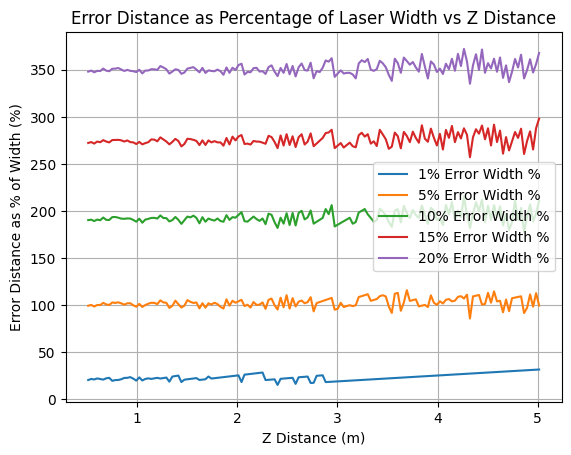

In [39]:
z_values = []
widths = []
heights = []

one_percent_error_distance = []
five_percent_error_distance = []
ten_percent_error_distance = []
fifteen_percent_error_distance = []
twenty_percent_error_distance = []

for idx in tqdm(range(s.shape[1])):
    if p[2, idx] < 0.5:
        continue

    center_x = s[0, idx]
    center_y = s[1, idx]

    width = s_right[0, idx] - s_left[0, idx]
    height = s_up[1, idx] - s_down[1, idx]

    heat_map = np.zeros((IMAGE_WIDTH, IMAGE_HEIGHT), dtype=float)

    x_range = np.arange(0, IMAGE_WIDTH)
    y_range = np.arange(0, IMAGE_HEIGHT)

    xy_grid = np.array(np.meshgrid(x_range, y_range, indexing='ij'))
    xy_homogeneous = np.vstack((xy_grid.reshape(2, -1), np.ones((1, xy_grid.shape[1] * xy_grid.shape[2]))))

    p_reconstructed, _ = reconstruct_points(xy_homogeneous, inverted_camera_intrinsics, laser_position, laser_direction)
    percent_errors = np.abs(p_reconstructed[2, :] - p[2, idx]) / p[2, idx] * 100
    distances = np.linalg.norm(xy_homogeneous[:2, :] - np.tile(s_pixel[:2, idx], (xy_homogeneous.shape[1], 1)).T, axis=0)

    one_percent_error_distance.append(distances[distances == np.min(distances[percent_errors > 1])][0])
    five_percent_error_distance.append(distances[distances == np.min(distances[percent_errors > 5])][0])
    ten_percent_error_distance.append(distances[distances == np.min(distances[percent_errors > 10])][0])
    fifteen_percent_error_distance.append(distances[distances == np.min(distances[percent_errors > 15])][0])
    twenty_percent_error_distance.append(distances[distances == np.min(distances[percent_errors > 20])][0])

    z_values.append(p[2, idx])
    widths.append(width)
    heights.append(height)

    if p[2, idx] > 5:
        break
    
one_percent_error_distance = np.array(one_percent_error_distance)
five_percent_error_distance = np.array(five_percent_error_distance)
ten_percent_error_distance = np.array(ten_percent_error_distance)
fifteen_percent_error_distance = np.array(fifteen_percent_error_distance)
twenty_percent_error_distance = np.array(twenty_percent_error_distance)

z_values = np.array(z_values)
widths = np.array(widths)
heights = np.array(heights)

one_percent_width_percent = one_percent_error_distance / widths * 100
one_percent_height_percent = one_percent_error_distance / heights * 100
five_percent_width_percent = five_percent_error_distance / widths * 100
five_percent_height_percent = five_percent_error_distance / heights * 100
ten_percent_width_percent = ten_percent_error_distance / widths * 100
ten_percent_height_percent = ten_percent_error_distance / heights * 100
fifteen_percent_width_percent = fifteen_percent_error_distance / widths * 100
fifteen_percent_height_percent = fifteen_percent_error_distance / heights * 100
twenty_percent_width_percent = twenty_percent_error_distance / widths * 100
twenty_percent_height_percent = twenty_percent_error_distance / heights * 100

plt.plot(z_values, one_percent_width_percent, label='1% Error Width %')
plt.plot(z_values, five_percent_width_percent, label='5% Error Width %')
plt.plot(z_values, ten_percent_width_percent, label='10% Error Width %')
plt.plot(z_values, fifteen_percent_width_percent, label='15% Error Width %')
plt.plot(z_values, twenty_percent_width_percent, label='20% Error Width %')
plt.xlabel('Z Distance (m)')
plt.ylabel('Error Distance as % of Width (%)')
plt.title('Error Distance as Percentage of Laser Width vs Z Distance')
plt.legend()
plt.grid()